Data exploration notebook

In [12]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import pandas as pd
import random
import numpy as np
import math
import collections
import tifffile as tiff


1. Data loading, checking and illisble files

In [13]:
# Importing the relevant data
data_path: Path = Path("/home/candidate/maia_261_jl/data/raw")

raw_data: pd.DataFrame = pd.read_csv(data_path / "data_info.csv", header=0, index_col=0)
raw_images_path: Path = data_path / "check-X-ray"

# Checking the data rows and columns IDs
print(f"CSV header :\n{raw_data.head()}\n")

print(f"CSV number of samples : {raw_data.shape[0]}")
all_images: list[Path] = list(raw_images_path.glob("*"))
print(f"Number of images in the dataset : {len(all_images)}\n")

for i, column in enumerate(raw_data.columns):
    print(f"Column {i}: {column}")

# Checking if there is no corrupted data
invalid_images: list[Path] = []

for image_path in all_images:
    try:
        with Image.open(image_path) as im:
            im.verify()
    except (UnidentifiedImageError, OSError) as e:
        invalid_images.append(image_path)
        print(f"File {image_path.name} could not be opened: {e}")
print(f"\nNumber of invalid files : {len(invalid_images)} over {len(all_images)} files\n")


CSV header :
  filename  label
0   0.tiff      0
1   1.tiff      0
2   2.tiff      0
3   3.tiff      0
4   4.tiff      0

CSV number of samples : 624
Number of images in the dataset : 624

Column 0: filename
Column 1: label

Number of invalid files : 0 over 624 files



2. NA values, labels, duplication checkings

In [14]:
# Checking if there are NA-Null values 
print(f"Number of NA values in the CSV : {raw_data.isna().sum().sum()}")

# Checking the different labels and if there is duplication in the files
print(f"Different label values : {raw_data['label'].unique()}")
print(f"Number of unique files : {raw_data['filename'].nunique()} over {len(raw_data['filename'])} files")

# No file cleaning since all the validity checks were completed


Number of NA values in the CSV : 0
Different label values : [0 1 2]
Number of unique files : 624 over 624 files


3. Checking if all the samples in the CSV are present in the image set and data leakage with metadata

In [15]:
# Check if all the data filenames can be found with the images
filenames_set: set = set(raw_data['filename'])
unavailable_images: list[Path] = []

for image_path in all_images:
    if not image_path.name in filenames_set:
        print(f"File {image_path.name} is not in the images set") 
        unavailable_images.append(image_path)
print(f"Number of images not present in the CSV : {len(unavailable_images)} over {len(all_images)} files")

# Exploring the tags in the TIFF metadata for one file
sample_path = next(raw_images_path.glob("*"))
with tiff.TiffFile(sample_path) as tif:
    print(f"\nAccessible metadata for file {sample_path.name}:")
    for tag in tif.pages[0].tags.values():
        print(f"{tag.name} ({tag.code}) : {tag.value}")

# Exploring the tags in the TIFF metadata for one file
tag_names: list[str] = []
for img_path in raw_images_path.glob("*"):
    with tiff.TiffFile(img_path) as tif:
        for tag in tif.pages[0].tags.values():
            tag_names.append(tag.name)

counter_tag_names: collections.Counter = collections.Counter(tag_names)
print(f"\nDifferent metadata tags : {counter_tag_names}")

# Could not evaluate data leakeage (patient radiography found multiple times) since no information is provided 
# on the patient ID 


Number of images not present in the CSV : 0 over 624 files

Accessible metadata for file 451.tiff:
ImageWidth (256) : 1600
ImageLength (257) : 992
BitsPerSample (258) : 8
Compression (259) : 1
PhotometricInterpretation (262) : 1
StripOffsets (273) : (122,)
RowsPerStrip (278) : 992
StripByteCounts (279) : (1587200,)
PlanarConfiguration (284) : 1

Different metadata tags : Counter({'ImageWidth': 624, 'ImageLength': 624, 'BitsPerSample': 624, 'Compression': 624, 'PhotometricInterpretation': 624, 'StripOffsets': 624, 'RowsPerStrip': 624, 'StripByteCounts': 624, 'PlanarConfiguration': 624})


4. Checking the class imbalance with plots chart and exact samples per categories values

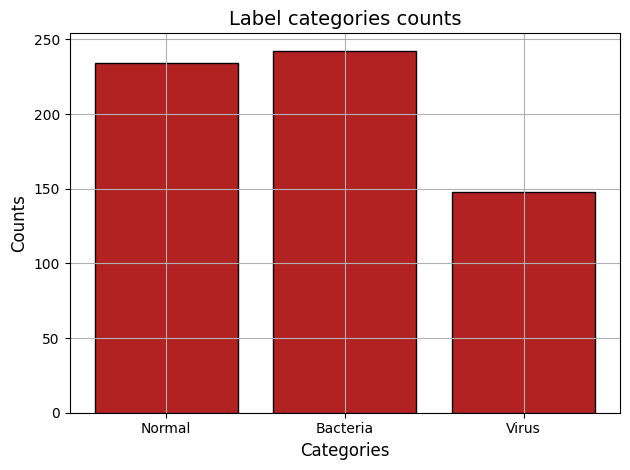

Number of samples per category (0:Normal, 1:Bacteria, 2:Virus) : 
label
1    242
0    234
2    148
Name: count, dtype: int64


In [16]:
# Displaying the plot charts of the classes distribution
label_counts = raw_data['label'].value_counts()
label_charts = plt.bar(label_counts.index, label_counts.values, color='firebrick', edgecolor='black')
plt.title('Label categories counts', fontsize=14)
plt.xlabel('Categories', fontsize=12)
plt.xticks([0, 1, 2], ['Normal', 'Bacteria', 'Virus'])
plt.ylabel('Counts', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Printing the exact values per category
print(f"Number of samples per category (0:Normal, 1:Bacteria, 2:Virus) : \n{raw_data['label'].value_counts()}")


5. Visualizing random images per label category

Number of samples in the normal CSV : 234 - in the original CSV : 234
Number of samples in the bacteria CSV : 242 - in the original CSV : 242
Number of samples in the virus CSV : 148 - in the original CSV : 148



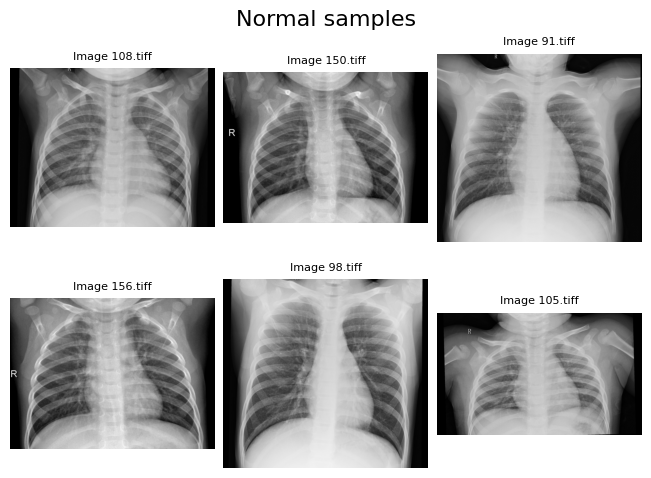

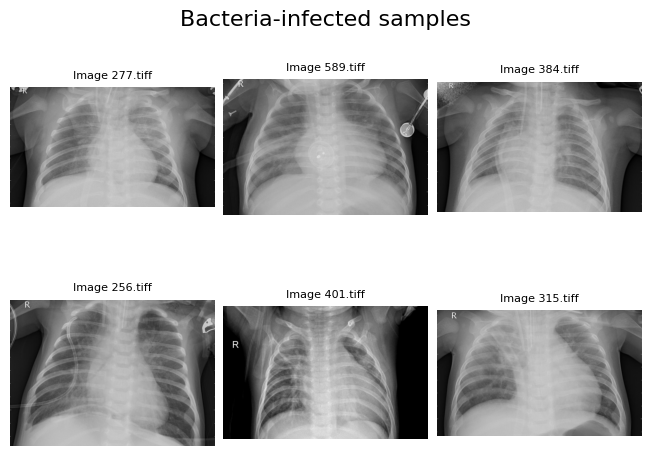

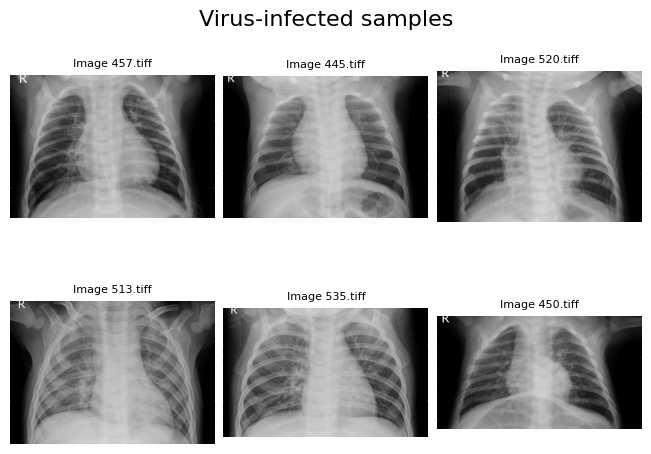

In [17]:
# Displaying some images per category
num_display_samples: int = 6
num_columns: int = 3
num_rows: int = math.ceil(num_display_samples / num_columns)

# Mapping each label category data into csv, to display files within
normal_csv: pd.DataFrame = raw_data[raw_data['label'] == 0].reset_index(drop=True)
bacteria_csv: pd.DataFrame = raw_data[raw_data['label'] == 1].reset_index(drop=True)
virus_csv: pd.DataFrame = raw_data[raw_data['label'] == 2].reset_index(drop=True)
analyzed_csv: list[pd.DataFrame] = [normal_csv, bacteria_csv, virus_csv]

# Checking if the number of samples in the new CSV match the original ones
print(f"Number of samples in the normal CSV : {normal_csv.shape[0]} - in the original CSV : {label_counts[0]}")
print(f"Number of samples in the bacteria CSV : {bacteria_csv.shape[0]} - in the original CSV : {label_counts[1]}")
print(f"Number of samples in the virus CSV : {virus_csv.shape[0]} - in the original CSV : {label_counts[2]}\n")

for i in analyzed_csv:
    figure_name: str = f"Normal samples" if i is normal_csv else \
        (f"Bacteria-infected samples" if i is bacteria_csv  else f"Virus-infected samples")
    display_figure: plt.Figure = plt.figure(layout="constrained")
    display_axes: np.ndarray = display_figure.subplots(nrows=num_rows, ncols=num_columns)
    display_figure.suptitle(figure_name, fontsize=16)

    for j in range(num_display_samples):
        display_sample_idx: int = random.randint(0, i.shape[0] - 1)

        filename: str = i['filename'][display_sample_idx]
        img_path: Path = raw_images_path / filename

        with Image.open(img_path) as pil_img:
            ax: plt.Axes = display_axes[
                j // num_columns, 
                j % num_columns
            ]
            ax.imshow(pil_img, cmap='gray')
            ax.set_title(f"Image {filename}", fontsize=8)
            ax.axis("off")
    plt.show()


6. Analyzing images format : RGB, grayscale, dtype, sizes histogram 

Number of files that are not tiff : 0 over 624 files
Number of files that are RGB : 0 over 624 files
Number of files that are grayscale : 624 over 624 files
Number of files that have a uint8 dtype : 624 over 624 files



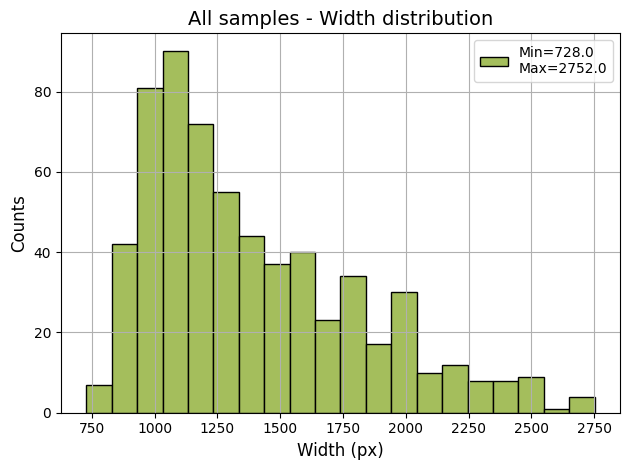

All samples Width mode : 952.0 pixels


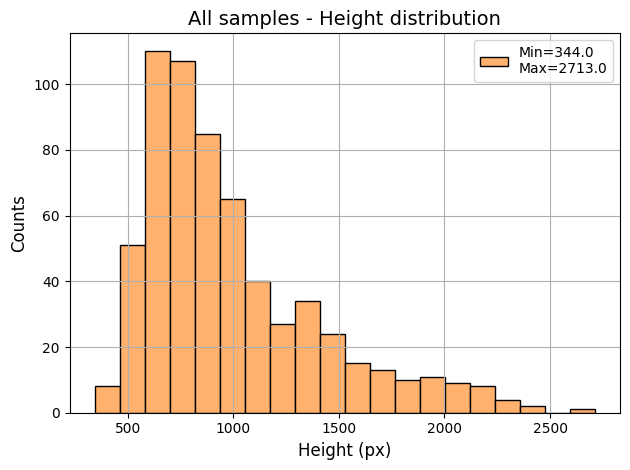

All samples Height mode : 696.0 pixels



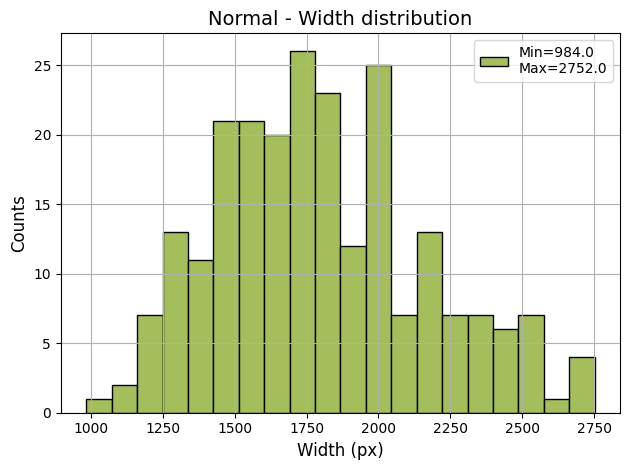

Normal Width mode : 1754.0 pixels


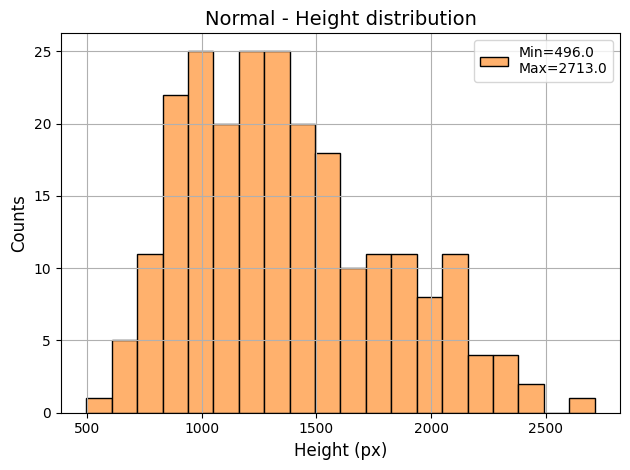

Normal Height mode : 1168.0 pixels



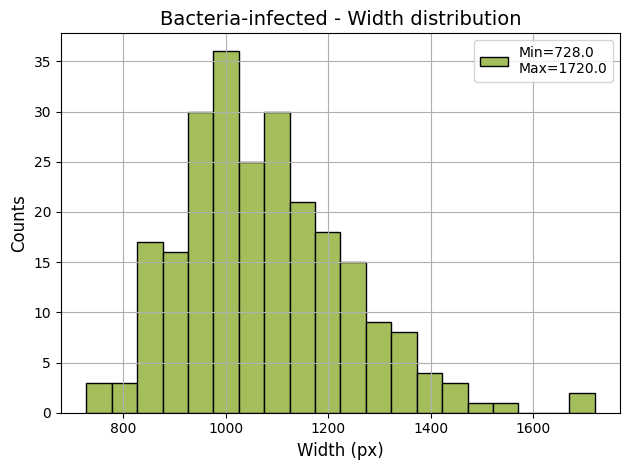

Bacteria-infected Width mode : 952.0 pixels


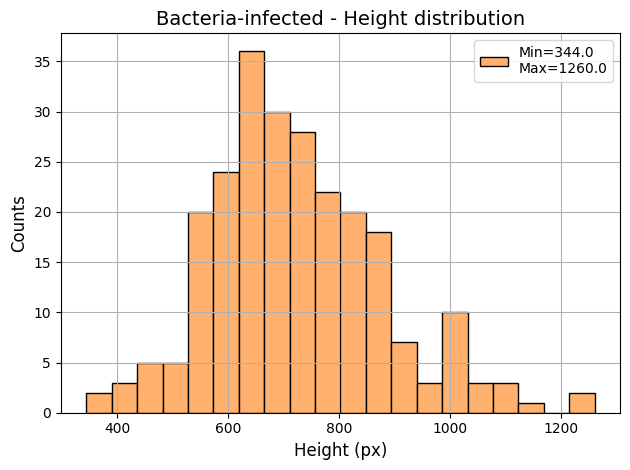

Bacteria-infected Height mode : 648.0 pixels



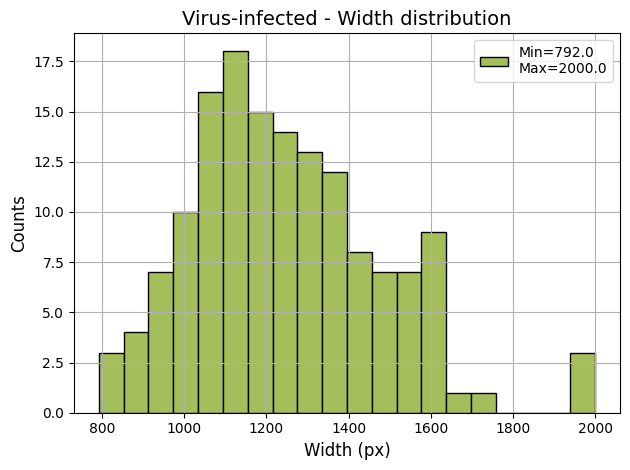

Virus-infected Width mode : 1120.0 pixels


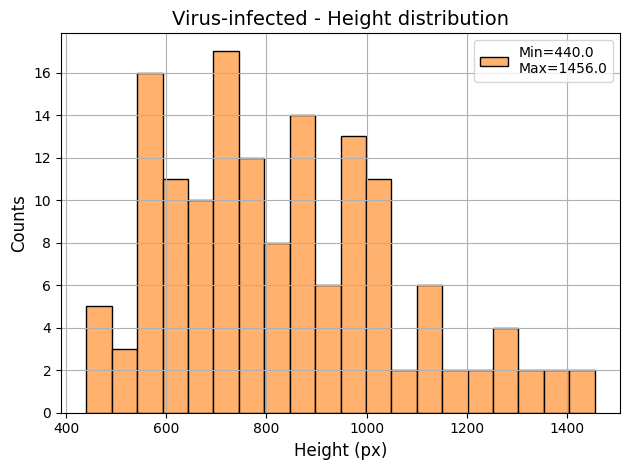

Virus-infected Height mode : 968.0 pixels



In [18]:
not_tiff_files: list[Path] = []
rgb_files: list[Path] = []
grayscale_files : list[Path] = []
uint8_files: list[Path] = []

# Checking if images are either at the RGB or grayscale format and their type
for img_path in raw_images_path.glob("*"):
    with Image.open(img_path) as img:
        if img.format != 'TIFF':
            not_tiff_files.append(img_path)

        if img.mode == 'RGB':
            rgb_files.append(img_path)
        elif img.mode == 'L':
            grayscale_files.append(img_path)

        img_array: np.ndarray = np.array(img)
        if img_array.dtype == 'uint8':
            uint8_files.append(img_path)

print(f"Number of files that are not tiff : {len(not_tiff_files)} over {len(all_images)} files")
print(f"Number of files that are RGB : {len(rgb_files)} over {len(all_images)} files")
print(f"Number of files that are grayscale : {len(grayscale_files)} over {len(all_images)} files")
print(f"Number of files that have a uint8 dtype : {len(uint8_files)} over {len(all_images)} files\n")

# Displaying the width and height distribution histograms (min, max and mode), per category
def plot_size_distribution(filenames: list[str], label_name: str) -> None:
    widths: list[int] = []
    heights: list[int] = []

    for filename in filenames:
        with Image.open(raw_images_path / filename) as img:
            img_w, img_h = img.size
            widths.append(img_w)
            heights.append(img_h)

    mode_w: float = collections.Counter(widths).most_common()[0][0]
    min_w, max_w = np.min(widths), np.max(widths)

    mode_h: float = collections.Counter(heights).most_common()[0][0]
    min_h, max_h = np.min(heights), np.max(heights)

    plt.hist(widths, bins=20, color='xkcd:light olive green', \
        edgecolor='black', label=f'Min={min_w:.1f}\nMax={max_w:.1f}')
    plt.title(f"{label_name} - Width distribution", fontsize=14)
    plt.xlabel("Width (px)", fontsize=12)
    plt.ylabel("Counts", fontsize=12)
    plt.tight_layout()
    plt.legend()
    plt.grid(True)
    plt.show()
    print(f"{label_name} Width mode : {mode_w:.1f} pixels")

    plt.hist(heights, bins=20, color='xkcd:apricot', \
        edgecolor='black', label=f'Min={min_h:.1f}\nMax={max_h:.1f}')
    plt.title(f"{label_name} - Height distribution", fontsize=14)
    plt.xlabel("Height (px)", fontsize=12)
    plt.ylabel("Counts", fontsize=12)
    plt.tight_layout()
    plt.legend()
    plt.grid(True)
    plt.show()
    print(f"{label_name} Height mode : {mode_h:.1f} pixels\n")

plot_size_distribution(raw_data['filename'], "All samples")
plot_size_distribution(normal_csv['filename'], "Normal")
plot_size_distribution(bacteria_csv['filename'], "Bacteria-infected")
plot_size_distribution(virus_csv['filename'], "Virus-infected")


7. Checking if the images have a pixel spacing (ps) value

In [19]:
# Checking if some files have the resolution (inverse of the ps) or not
images_without_ps: list[Path] = []
unit_values: list[int | None] = []

for img_path in raw_images_path.glob("*"):
    with tiff.TiffFile(img_path) as tif:
        tags = tif.pages[0].tags
        x_res = tags.get('XResolution')
        y_res = tags.get('YResolution')
        unit = tags.get('ResolutionUnit')

        # Saving the resolution unit
        unit_value = unit.value if unit is not None else None
        unit_values.append(unit_value)

        # Saving all the files without a valid pixel spacing (no resolution unit, equals also 1)
        if x_res is None or y_res is None or unit is None or unit_value==1:
            images_without_ps.append(img_path)
print(f"\nNumber of files without the resolution, and thus no ps : {len(images_without_ps)} over {len(all_images)}")

# Checking the resolution available units
print(f"Resolution available values : {collections.Counter(unit_values)}")



Number of files without the resolution, and thus no ps : 624 over 624
Resolution available values : Counter({None: 624})


8. Images intensity : mean/std, global and per classes pixel intensities histograms

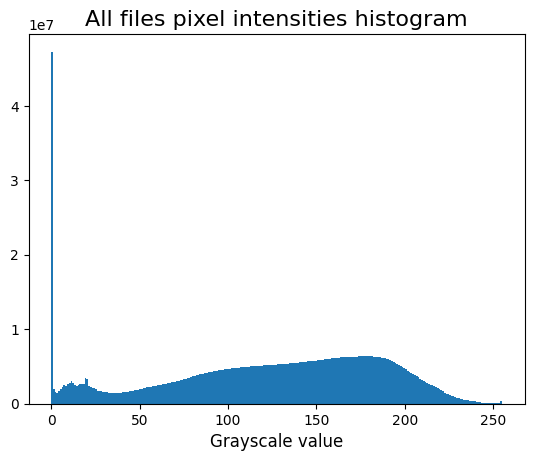

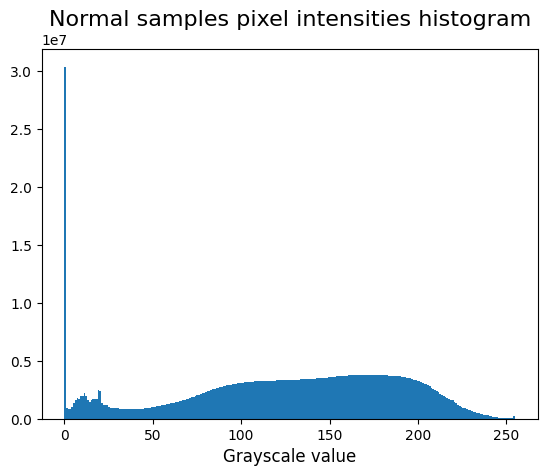

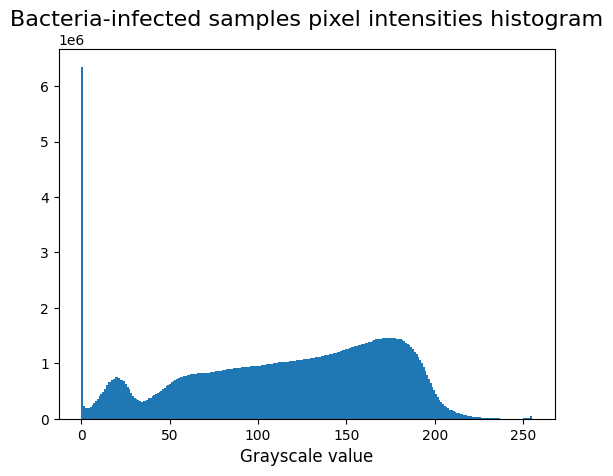

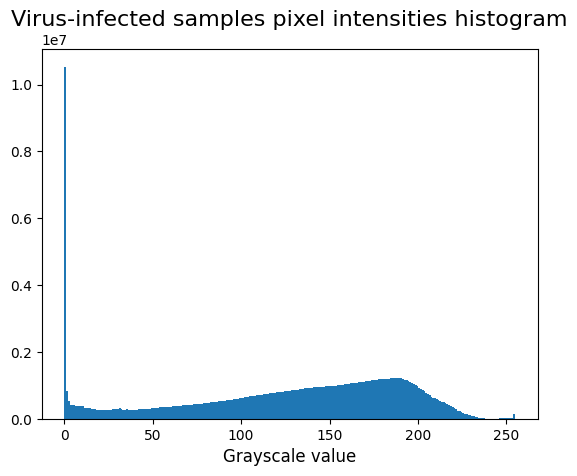

Normal samples - mean : 124.1 - std : 60.2
Bacteria-infected samples - mean : 116.5 - std : 52.6
Virus-infected samples - mean : 123.7 - std : 61.4


In [20]:
def get_pixel_intensities(
        csv: pd.DataFrame
    ) -> np.ndarray:
    pixel_intensities: list[np.ndarray] = []
    for filename in csv['filename']:
        img_path = raw_images_path / filename
        with Image.open(img_path) as img:
            img_array: np.ndarray = np.array(img)
            # Convert into an array (tabular) anf flatten the values
            pixel_intensities.append(img_array.flatten())
    # Concatenate the list of all the 1D vectors of different sizes into one variable
    return np.concatenate(pixel_intensities)

def displaying_histograms(
        pixel_intensities: np.ndarray,
        histogram_name: str
    ) -> None:
    _, ax = plt.subplots()
    ax.hist(pixel_intensities, bins=256,range=(0, 255))
    ax.set_title(histogram_name, fontsize=16)
    ax.set_xlabel("Grayscale value", fontsize=12)
    plt.show()

# Printing the histogram of the images pixel intensity for all the files
all_files_pixel_intensities: np.ndarray = get_pixel_intensities(raw_data)
all_files_hist_name: str = f'All files pixel intensities histogram'
displaying_histograms(all_files_pixel_intensities, all_files_hist_name)

# Printing the histogram of the images pixel intensity per label categories
normal_pixel_intensities: np.ndarray = get_pixel_intensities(normal_csv)
normal_hist_name: str = f'Normal samples pixel intensities histogram'
displaying_histograms(normal_pixel_intensities, normal_hist_name)

bacteria_pixel_intensities: np.ndarray = get_pixel_intensities(bacteria_csv)
bacteria_hist_name: str = f'Bacteria-infected samples pixel intensities histogram'
displaying_histograms(bacteria_pixel_intensities, bacteria_hist_name)

virus_pixel_intensities: np.ndarray = get_pixel_intensities(virus_csv)
virus_hist_name: str = f'Virus-infected samples pixel intensities histogram'
displaying_histograms(virus_pixel_intensities, virus_hist_name)

# Computing the pixel intensities values mean and standard deviation per class 
# To see whether or not the images need a contrast enhancement in future steps
def compute_mean_std(
        csv: pd.DataFrame
    ) -> tuple[float, float]:
    img_means: list[float] = []
    img_stds: list[float] = []
    for filename in csv['filename']:
        img_path = raw_images_path / filename
        with Image.open(img_path) as img:
            img_array: np.ndarray = np.array(img)
            # Computing the mean and std per file
            mean: float = np.mean(img_array)
            std: float = np.std(img_array)
            img_means.append(mean)
            img_stds.append(std)
    # Mean for all the images in the csv
    return np.mean(img_means), np.mean(img_stds)

print(f"Normal samples - mean : {compute_mean_std(normal_csv)[0]:.1f} - std : {compute_mean_std(normal_csv)[1]:.1f}")
print(f"Bacteria-infected samples - mean : {compute_mean_std(bacteria_csv)[0]:.1f} - std : {compute_mean_std(bacteria_csv)[1]:.1f}")
print(f"Virus-infected samples - mean : {compute_mean_std(virus_csv)[0]:.1f} - std : {compute_mean_std(virus_csv)[1]:.1f}")


Conclusions : 

In all these exploratory steps, including for instance data validity checking, class imbalances, data leakage, images sizes and pixel intensity values checking and more, we came to different conclusions. First, our loaded images match the filename column in our CSV: we found out that our set of 624 valid images matched the 624 unique samples in the dataframe, with no missing value (NA). We have also checked the metadata of our files (TIFF format) and pointed out no information relative to the patient identification, such as an ID. We couldn't then determine if multiple images were associated to the same patient, as a major data leakage risk during the training and testing phases. Our three labels are: 0 (Normal), 1 (Bacteria-Infected) and 2 (Virus-Infected), amounting to 234, 242 and 148 respectively. By displaying the plots of the label categories counts, we shed light on class imbalance. Indeed, the Virus-Infected samples are fewer in number. We shall then take that into account. We have likewise visualized some random images per category and found out that all images have the TIFF format, are Grayscale (confirmed with the PhotometricInterpretation metadata) and have a unint8 dtype (confirmed with the BitsPerSample metadata). Images also have different widths and height, with no relative information about their resolution and thus, pixel spacing, in their metadata. The normal label catgory has also bigger images in width and height than other label categories. It points out that a possible acquisition biais, based on the label category. We shall then resize images at the same size, so that our model won't learn only on huge dimensions images for normal samples, and tiny images for other label categories. Finally, our histograms and computed mean/std on the each files category illustrate that some parts of the images are entirely black as background black pixels (with the 0 intensity histograms peak) and that the pixel intensities are equilibrated without too much contrast. In fact, with a std of 60 approximately divided by the maximum contrast value of 127.5, we found that our images have 40 to 50 % of contrast. We could afterwards correct this this value by enhancing the contrast in further preprocessing steps. 